Setup, Basic Libraraies, and cashing

In [600]:
#install FastF1
!pip install fastf1

# Import basic libraries and enable cache
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# create a Cahce folder to speed up the repeated data fetch process
os.makedirs('fastf1_cache', exist_ok=True)

fastf1.Cache.enable_cache('fastf1_cache')

Load session & exploring data

In [601]:
# Load Canada Race session (2024)
race_2024 = fastf1.get_session(2024, 'Canada', 'R') # R = Race
race_2024.load()

print("Race loaded", race_2024.event['EventName'], "-", race_2024.event['Location'])

# Extract labs and View the Data structure
df_race = race_2024.laps.copy()
# View the first 5 rows
display(df_race.head())

print(f"Columns: {df_race.columns.tolist()}")
print(f"Number of laps: {df_race.shape[0]}")

#Data types and missing values
df_race.info()

#Data summary
df_race.describe()


core           INFO 	Loading data for Canadian Grand Prix - Race [v3.6.0]
INFO:fastf1.fastf1.core:Loading data for Canadian Grand Prix - Race [v3.6.0]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core       

Race loaded Canadian Grand Prix - Montréal


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:05:50.866000,VER,1,0 days 00:01:44.993000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:31.826000,...,True,Red Bull Racing,0 days 00:04:05.608000,2024-06-09 18:03:11.605,12,2.0,False,,False,False
1,0 days 00:07:28.538000,VER,1,0 days 00:01:37.672000,2.0,1.0,NaT,NaT,0 days 00:00:28.815000,0 days 00:00:31.274000,...,True,Red Bull Racing,0 days 00:05:50.866000,2024-06-09 18:04:56.863,1,2.0,False,,False,True
2,0 days 00:09:04.981000,VER,1,0 days 00:01:36.443000,3.0,1.0,NaT,NaT,0 days 00:00:28.620000,0 days 00:00:31.275000,...,True,Red Bull Racing,0 days 00:07:28.538000,2024-06-09 18:06:34.535,1,2.0,False,,False,True
3,0 days 00:10:40.086000,VER,1,0 days 00:01:35.105000,4.0,1.0,NaT,NaT,0 days 00:00:28.103000,0 days 00:00:30.649000,...,True,Red Bull Racing,0 days 00:09:04.981000,2024-06-09 18:08:10.978,1,2.0,False,,False,True
4,0 days 00:12:13.945000,VER,1,0 days 00:01:33.859000,5.0,1.0,NaT,NaT,0 days 00:00:27.574000,0 days 00:00:30.293000,...,True,Red Bull Racing,0 days 00:10:40.086000,2024-06-09 18:09:46.083,1,2.0,False,,False,True


Columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
Number of laps: 1272
<class 'fastf1.core.Laps'>
RangeIndex: 1272 entries, 0 to 1271
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                1272 non-null   timedelta64[ns]
 1   Driver              1272 non-null   object         
 2   DriverNumber        1272 non-null   object         
 3   LapTime             1267 non-null   timedelta64[ns]
 4   LapNumber           1272 non-null   float64        
 5   Stint               1272 non-null   f

,Time,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,TyreLife,LapStartTime,LapStartDate,Position
count,1272,1267,1272.000000,1272.000000,44,45,1250,1270,1267,1250,1270,1267,1193.000000,1270.000000,1225.000000,1270.000000,1272.000000,1272,1270,1270.000000
mean,0 days 00:56:21.167585691,0 days 00:01:31.457970797,33.495283,1.997642,0 days 00:56:34.737272727,0 days 01:00:02.210244444,0 days 00:00:26.277312800,0 days 00:00:28.879967716,0 days 00:00:36.100168113,0 days 00:56:04.115688,0 days 00:55:44.532354330,0 days 00:56:17.281369376,214.533110,266.137008,269.489796,289.821260,12.485063,0 days 00:54:49.788138364,2024-06-09 18:53:55.103462144,9.678740
min,0 days 00:05:49.596000,0 days 00:01:14.856000,1.000000,1.000000,0 days 00:04:17.809000,0 days 00:15:20.353000,0 days 00:00:21.061000,0 days 00:00:23.671000,0 days 00:00:29.890000,0 days 00:06:17.920000,0 days 00:05:12.070000,0 days 00:05:49.775000,86.000000,122.000000,117.000000,65.000000,1.000000,0 days 00:04:05.608000,2024-06-09 18:03:11.605000,1.000000
25%,0 days 00:29:51.853750,0 days 00:01:24.455000,16.000000,1.000000,0 days 00:43:12.011250,0 days 00:42:56.411000,0 days 00:00:24.752000,0 days 00:00:26.758500,0 days 00:00:32.574000,0 days 00:30:00.321250,0 days 00:29:16.617250,0 days 00:29:46.319500,200.000000,268.000000,270.000000,299.000000,6.000000,0 days 00:28:22.575500,2024-06-09 18:27:27.439500032,5.000000
50%,0 days 00:56:31.467000,0 days 00:01:28.248000,33.000000,2.000000,0 days 01:01:02.911500,0 days 01:09:30.763000,0 days 00:00:25.809500,0 days 00:00:28.077000,0 days 00:00:34.020000,0 days 00:55:41.126500,0 days 00:55:57.611000,0 days 00:56:29.335000,221.000000,275.000000,274.000000,304.000000,11.000000,0 days 00:55:02.171500,2024-06-09 18:54:08.168499968,10.000000
75%,0 days 01:21:12.271250,0 days 00:01:34.571000,50.000000,3.000000,0 days 01:12:50.067500,0 days 01:12:28.952000,0 days 00:00:27.435250,0 days 00:00:29.984750,0 days 00:00:36.470000,0 days 01:20:21.800500,0 days 01:20:40.685500,0 days 01:21:10.954500,235.000000,279.000000,279.000000,309.000000,18.000000,0 days 01:19:52.650250,2024-06-09 19:18:58.322500096,14.000000
max,0 days 01:50:47.328000,0 days 00:02:25.739000,70.000000,5.000000,0 days 01:27:46.488000,0 days 01:27:19.574000,0 days 00:00:41.378000,0 days 00:00:55.514000,0 days 00:01:31.454000,0 days 01:49:51.762000,0 days 01:50:16.062000,0 days 01:50:47.328000,262.000000,289.000000,300.000000,347.000000,44.000000,0 days 01:49:29.708000,2024-06-09 19:48:35.705000,20.000000
std,0 days 00:30:17.486492435,0 days 00:00:12.611833756,19.813330,1.025633,0 days 00:21:11.296627635,0 days 00:18:27.888264513,0 days 00:00:03.231378267,0 days 00:00:03.879907359,0 days 00:00:06.862403727,0 days 00:29:53.631514656,0 days 00:30:19.020089701,0 days 00:30:18.826225102,31.238245,27.947662,23.351676,49.014612,8.414129,0 days 00:30:21.497204231,NaN,5.403274


Cleaning data

In [602]:
print(f"Shape of df_race before cleaning: {df_race.shape}")

df_race_cleaned = df_race.copy()

# Define the time and numeric columns
time_columns = ['Time', 'LapTime', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'LapStartTime']

# Convert timedelta columns to total seconds (float)
for col in time_columns:
    if col in df_race_cleaned.columns and pd.api.types.is_timedelta64_dtype(df_race_cleaned[col]):
        df_race_cleaned[col + "s"] = df_race_cleaned[col].dt.total_seconds()


# Drop bad laps
mask_clean = (
    df_race_cleaned['IsAccurate'].eq(True) &
    df_race_cleaned['Deleted'].eq(False) &
    df_race_cleaned['TrackStatus'].fillna('1').eq('1') &
    df_race_cleaned['PitInTime'].isna() &
    df_race_cleaned['PitOutTime'].isna() &
    df_race_cleaned['LapTime'].notna()
)

df_race_cleaned = df_race_cleaned[mask_clean].copy()

# Remove extrem lap times
df_race_cleaned = df_race_cleaned[df_race_cleaned['LapTimes'].between(70, 120).copy()]

# Double check missing data
missing_values = df_race_cleaned.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])


display(df_race_cleaned.head())


Shape of df_race before cleaning: (1272, 31)
Missing values in each column:
PitOutTime     892
PitInTime      892
SpeedI1         65
PitOutTimes    892
PitInTimes     892
dtype: int64


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapTimes,PitOutTimes,PitInTimes,Sector1Times,Sector2Times,Sector3Times,Sector1SessionTimes,Sector2SessionTimes,Sector3SessionTimes,LapStartTimes
1,0 days 00:07:28.538000,VER,1,0 days 00:01:37.672000,2.0,1.0,NaT,NaT,0 days 00:00:28.815000,0 days 00:00:31.274000,...,97.672,NaN,NaN,28.815,31.274,37.583,379.713,410.987,448.570,350.866
2,0 days 00:09:04.981000,VER,1,0 days 00:01:36.443000,3.0,1.0,NaT,NaT,0 days 00:00:28.620000,0 days 00:00:31.275000,...,96.443,NaN,NaN,28.620,31.275,36.548,477.190,508.465,545.013,448.538
3,0 days 00:10:40.086000,VER,1,0 days 00:01:35.105000,4.0,1.0,NaT,NaT,0 days 00:00:28.103000,0 days 00:00:30.649000,...,95.105,NaN,NaN,28.103,30.649,36.353,573.116,603.765,640.118,544.981
4,0 days 00:12:13.945000,VER,1,0 days 00:01:33.859000,5.0,1.0,NaT,NaT,0 days 00:00:27.574000,0 days 00:00:30.293000,...,93.859,NaN,NaN,27.574,30.293,35.992,667.692,697.985,733.977,640.086
6,0 days 00:15:17.837000,VER,1,0 days 00:01:31.258000,7.0,1.0,NaT,NaT,0 days 00:00:26.610000,0 days 00:00:29.509000,...,91.258,NaN,NaN,26.610,29.509,35.139,853.221,882.730,917.869,826.579


Detect outliers

Before IQR filtering: 892 laps
After IQR filtering: 875 laps
Laps removed: 17


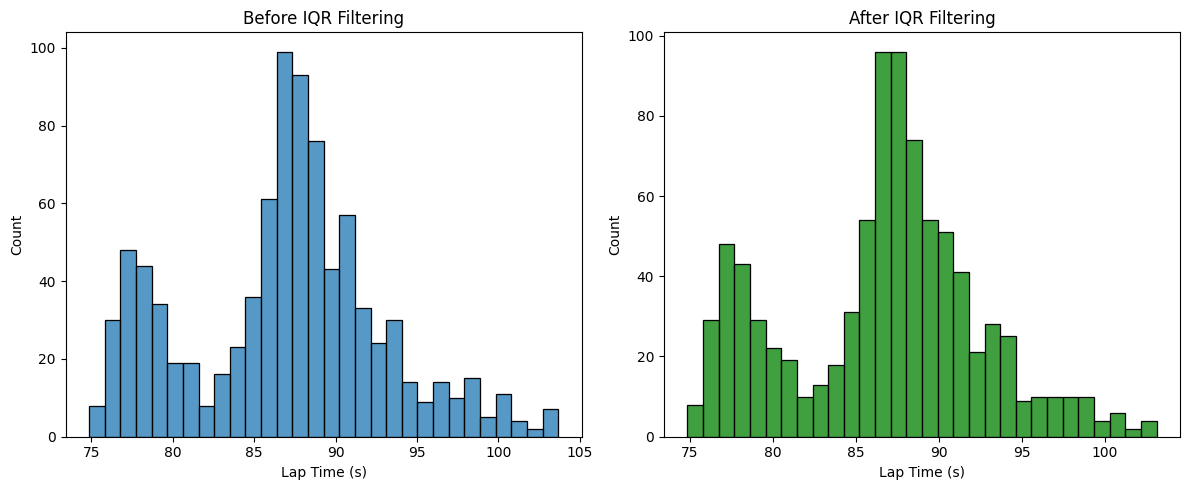

In [603]:
# IQR Outlier Removal for Lap Times
df_iqr = df_race_cleaned.copy()

# Group by driver so each driver is compared only to their own laps
def remove_outliers_iqr(group, col='LapTimes'):
    Q1 = group[col].quantile(0.25)
    Q3 = group[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return group[(group[col] >= lower_bound) & (group[col] <= upper_bound)]

# Apply to each driver group
df_iqr = df_iqr.groupby('Driver', group_keys=False).apply(remove_outliers_iqr).reset_index(drop=True)

print(f"Before IQR filtering: {df_race_cleaned.shape[0]} laps")
print(f"After IQR filtering: {df_iqr.shape[0]} laps")
print(f"Laps removed: {df_race_cleaned.shape[0] - df_iqr.shape[0]}")

# Quick pace distribution plots before vs after
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df_race_cleaned['LapTimes'], bins=30)
plt.title("Before IQR Filtering")
plt.xlabel("Lap Time (s)")

plt.subplot(1,2,2)
sns.histplot(df_iqr['LapTimes'], bins=30, color='green')
plt.title("After IQR Filtering")
plt.xlabel("Lap Time (s)")
plt.tight_layout()
plt.show()

Aggregate sector times by driver

In [604]:
sector_times_2024 = (
    df_iqr.groupby("Driver")
    .agg({
        "Sector1Times": "mean",
        "Sector2Times": "mean",
        "Sector3Times": "mean"
    })
    .reset_index()
)

sector_times_2024["TotalSectorTimes"] = (
    sector_times_2024["Sector1Times"] +
    sector_times_2024["Sector2Times"] +
    sector_times_2024["Sector3Times"]
)

display(sector_times_2024)


,Driver,Sector1Times,Sector2Times,Sector3Times,TotalSectorTimes
0,ALB,26.131343,28.195600,34.109771,88.436714
1,ALO,24.995959,27.259367,33.381735,85.637061
2,BOT,25.576898,27.829163,33.851061,87.257122
3,GAS,25.524720,27.602720,33.582380,86.709820
4,HAM,25.001939,27.139490,33.266490,85.407918
5,HUL,25.403660,27.490915,33.457723,86.352298
6,LEC,26.680852,28.776630,35.038704,90.496185
7,MAG,25.271128,27.403128,33.517851,86.192106
8,NOR,24.657043,27.077149,33.038809,84.773000
9,OCO,25.367340,27.749500,33.739680,86.856520


clean air race pac

In [605]:
# Create clean air race pace
clean_air_race_pace_2024 = dict(zip(sector_times_2024["Driver"], sector_times_2024["TotalSectorTimes"]))

print("Clean Air Race Pace (s) per driver:")
for driver, pace in clean_air_race_pace_2024.items():
    print(f"{driver}: {pace:.3f}")


Clean Air Race Pace (s) per driver:
ALB: 88.437
ALO: 85.637
BOT: 87.257
GAS: 86.710
HAM: 85.408
HUL: 86.352
LEC: 90.496
MAG: 86.192
NOR: 84.773
OCO: 86.857
PER: 88.173
PIA: 85.494
RIC: 86.742
RUS: 85.497
SAI: 88.801
SAR: 89.720
STR: 86.548
TSU: 86.861
VER: 85.230
ZHO: 87.846


Quali data from Canada GP

core           INFO 	Loading data for Canadian Grand Prix - Qualifying [v3.6.0]
INFO:fastf1.fastf1.core:Loading data for Canadian Grand Prix - Qualifying [v3.6.0]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req       

2024 Canadian Qualifying Times:
  Driver  QualifyingTimes
0    RUS           71.742
1    HAM           71.979
2    VER           72.000
3    NOR           72.021
4    PIA           72.103
5    RIC           72.178
6    ALO           72.228
7    TSU           72.303
8    ALB           72.485
9    STR           72.659
2024 Canadian Qualifying Times with Clean Air Race Pace:
  Driver  QualifyingTimes  CleanAirRacePace
0    RUS           71.742         85.497065
1    HAM           71.979         85.407918
2    VER           72.000         85.230490
3    NOR           72.021         84.773000
4    PIA           72.103         85.494140
5    RIC           72.178         86.741673
6    ALO           72.228         85.637061
7    TSU           72.303         86.860940
8    ALB           72.485         88.436714
9    STR           72.659         86.548061
2024_Canadian_Qualifying_Times_with_Clean_Air_Race_Pace.csv is being saved


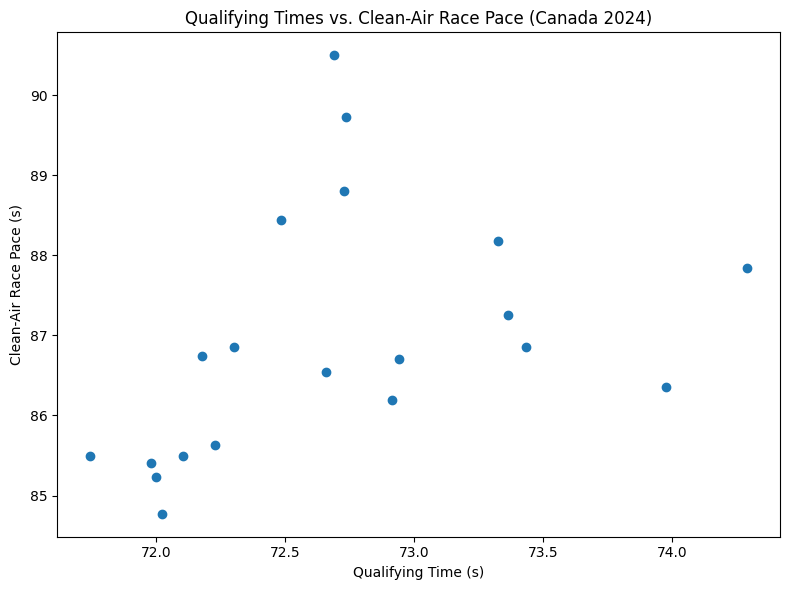

In [606]:
# Load 2024 Qualify session
qualify_2024 = fastf1.get_session(2024, 'Canada', 'Q')
qualify_2024.load()

laps_q = qualify_2024.laps.copy()

#Fetch fastest time per driver
drivers = qualify_2024.drivers
qualyTime_2024 = []
for driver_number in drivers:
    driver_info = qualify_2024.get_driver(driver_number)
    driver_abbr = driver_info['Abbreviation']

    driver_laps = laps_q.pick_driver(driver_abbr)
    if driver_laps.empty:
        continue

    best_lap = driver_laps.pick_fastest()
    if best_lap is None or pd.isna(best_lap['LapTime']):
        continue

    qualyTime_2024.append({'Driver': driver_abbr, 'QualifyingTimes': best_lap['LapTime'].total_seconds()})

# Convert to DataFrame
df_qualify = (pd.DataFrame(qualyTime_2024).sort_values(by='QualifyingTimes').reset_index(drop=True))
#
print("2024 Canadian Qualifying Times:")
print(df_qualify.head(10))


# Map to qualifying table
df_qualify['CleanAirRacePace'] = df_qualify['Driver'].map(clean_air_race_pace_2024)

# Keep onl drivers in both
df_qualify_pace = df_qualify.dropna(subset=['CleanAirRacePace']).reset_index(drop=True)
df_qualify_pace = df_qualify_pace.sort_values(by='QualifyingTimes')

print("2024 Canadian Qualifying Times with Clean Air Race Pace:")
print(df_qualify_pace.head(10))

df_qualify_pace.to_csv('2024_Canadian_Qualifying_Times_with_Clean_Air_Race_Pace.csv', index=False)
print('2024_Canadian_Qualifying_Times_with_Clean_Air_Race_Pace.csv is being saved')

# plot Qualifying Times & Clean-Air Race Pace
plt.figure(figsize=(8,6))
plt.scatter(df_qualify_pace['QualifyingTimes'], df_qualify_pace['CleanAirRacePace'])
plt.xlabel('Qualifying Time (s)')
plt.ylabel('Clean-Air Race Pace (s)')
plt.title('Qualifying Times vs. Clean-Air Race Pace (Canada 2024)')
plt.tight_layout()
plt.show()

Get weather Data for Canada

In [607]:
import requests
from datetime import datetime, timezone, timedelta

# Qualifying time session window from FatF1
qualify_start = qualify_2024.session_info['StartDate']
qualify_end = qualify_2024.session_info['EndDate']

def to_utc(dt):
  if getattr(dt, "tzinfo", None) is None:
    return dt.replace(tzinfo=timezone.utc)
  return dt.astimezone(timezone.utc)


qualify_start_utc = to_utc(qualify_start)
qualify_end_utc = to_utc(qualify_end)

# Montréal circuit location
montreal_lat = 45.5016
montreal_lon = -73.567

# Archive vs Forcast
now_utc = datetime.now(timezone.utc)
use_archive = qualify_end_utc < now_utc

api = "https://archive-api.open-meteo.com/v1/archive" if use_archive else "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": montreal_lat,
    "longitude": montreal_lon,
    "hourly": "temperature_2m,relative_humidity_2m,windspeed_10m,precipitation,precipitation_probability",
    "timezone": "UTC"
}

if use_archive:
    params["start_date"] = qualify_start_utc.strftime("%Y-%m-%d")
    params["end_date"] = qualify_end_utc.strftime("%Y-%m-%d")
else:
    params["forecast_days"] = 7

print("API selected:", api)
print("Archive data used:", use_archive)
print("Params:", {k: v for k, v in params.items() if k in ("start_date","end_date","forecast_days")})

# Request API
response = requests.get(api, params=params, timeout=30)
response.raise_for_status()
data = response.json()

# Hourly DataFrame
hourly = data.get("hourly", {})
df_hourly = pd.DataFrame(hourly)

if df_hourly.empty:
    print("No hourly data available.")
else:
    df_hourly['time'] = pd.to_datetime(df_hourly['time'])
    df_hourly = df_hourly.set_index('time')

# Renam weather columns
# Rename weather columns for consistency right after creating df_hourly
df_hourly = df_hourly.rename(columns={
    "temperature_2m": "Temperature",
    "relative_humidity_2m": "Humidity",
    "windspeed_10m": "WindSpeedKmh",
    "precipitation": "RainMm",
    "precipitation_probability": "RainProbability"
})


display(df_hourly.head(20))

API selected: https://archive-api.open-meteo.com/v1/archive
Archive data used: True
Params: {'start_date': '2024-06-08', 'end_date': '2024-06-08'}


,Temperature,Humidity,WindSpeedKmh,RainMm,RainProbability
time,,,,,
2024-06-08 00:00:00,18.4,72,11.9,0.0,None
2024-06-08 01:00:00,16.3,85,9.5,0.0,None
2024-06-08 02:00:00,15.9,88,13.8,0.0,None
2024-06-08 03:00:00,15.6,89,14.7,0.0,None
2024-06-08 04:00:00,14.9,89,18.9,0.3,None
2024-06-08 05:00:00,14.7,91,16.2,0.2,None
2024-06-08 06:00:00,14.4,93,14.2,0.0,None
2024-06-08 07:00:00,13.9,94,11.4,0.0,None
2024-06-08 08:00:00,13.9,93,13.0,0.0,None


Adjust qualifying time based on weather conditions

In [608]:
# Merge weather conditions

# Best start time lap for each driver
# The 'LapStartDate' is already available and in datetime format from the previous steps.
best_idx = laps_q.groupby("Driver")["LapTime"].idxmin()
best_lap_time = laps_q.loc[best_idx, ["Driver", "LapTime", "LapStartDate"]].reset_index(drop=True)

# Ensure the type is datetime for df_hourly index
df_hourly.index = pd.to_datetime(df_hourly.index)

# Merge driver's best lap with weather condition
best_lap_weather = []
for index, row in best_lap_time.iterrows():
    driver = row['Driver']
    lap_datetime = row['LapStartDate']

    # Find the nearest weather data based on LapStartDate (datetime)
    try:
        nearest_weather_time = df_hourly.index.get_indexer([lap_datetime], method='nearest')[0]
        weather_data = df_hourly.iloc[nearest_weather_time]
        best_lap_weather.append({
            "Driver": driver,
            "Temperature": weather_data["Temperature"],
            "Humidity": weather_data["Humidity"],
            "WindSpeedKmh": weather_data["WindSpeedKmh"],
            "RainMm": weather_data.get("RainMm", 0.0),
            "RainProbability": weather_data.get("RainProbability", 0.0)
        })
    except IndexError:
        # Handle cases where no nearest time is found
        print(f"Warning: No weather data found near {lap_datetime} for driver {driver}")
        best_lap_weather.append({
            'Driver': driver,
            'Temperature': None,
            'Humidity': None,
            'WindSpeedKmh': None,
            'RainMm': None,
            'RainProbability': None
        })


df_weather = pd.DataFrame(best_lap_weather)

# Merge with df_qualify_pace
final_df = pd.merge(df_qualify_pace, df_weather, on='Driver', how='left')


# make sure the rain, rain probability is numeric
final_df['RainMm'] = pd.to_numeric(final_df['RainMm'], errors='coerce').fillna(0)
final_df['RainProbability'] = pd.to_numeric(final_df['RainProbability'], errors='coerce').fillna(0)

# Add rain flag
final_df['is_rain'] = final_df['RainMm'].apply(lambda x: 1 if x and x > 0.05 else 0)

#Preview final dataset
display(final_df.head(20))

,Driver,QualifyingTimes,CleanAirRacePace,Temperature,Humidity,WindSpeedKmh,RainMm,RainProbability,is_rain
0,RUS,71.742,85.497065,20.4,59,26.3,0.0,0.0,0
1,HAM,71.979,85.407918,20.4,59,26.3,0.0,0.0,0
2,VER,72.000,85.230490,20.4,59,26.3,0.0,0.0,0
3,NOR,72.021,84.773000,20.4,59,26.3,0.0,0.0,0
4,PIA,72.103,85.494140,20.4,59,26.3,0.0,0.0,0
5,RIC,72.178,86.741673,20.4,59,26.3,0.0,0.0,0
6,ALO,72.228,85.637061,20.4,59,26.3,0.0,0.0,0
7,TSU,72.303,86.860940,20.4,59,26.3,0.0,0.0,0
8,ALB,72.485,88.436714,20.4,59,26.3,0.0,0.0,0
9,STR,72.659,86.548061,20.4,59,26.3,0.0,0.0,0


In [609]:
# Get constructor standings for the 2024 Canadian GP
# Access constructor standings from the results attribute of the session
# The results attribute is a DataFrame containing driver results, which includes constructor info and points
results_df = race_2024.results

# Filter for constructors and their points
constructor_standings_df = results_df[['TeamName', 'Points']].groupby('TeamName').sum().reset_index()

# Create dict of team points
team_points = {row['TeamName']: row['Points'] for _, row in constructor_standings_df.iterrows()}

# Normalize to max points
max_points = max(team_points.values())
team_performance_score = {team: pts / max_points for team, pts in team_points.items()}

print(team_performance_score)

# Map driver to team
driver_to_team = results_df.set_index('Abbreviation')['TeamName'].to_dict()

# Add team info th final data set
final_df['Team'] = final_df['Driver'].map(driver_to_team)

# Add teamm performance score
final_df['TeamPerformanceScore'] = final_df['Team'].map(team_performance_score)

# Calculate Averag Position from race (quali pos - finish pos)
pos_df = results_df[['Abbreviation', 'GridPosition','Position']].copy()
# Ensure numeric values
pos_df['GridPosition'] = pd.to_numeric(pos_df['GridPosition'], errors='coerce')
pos_df['Position'] = pd.to_numeric(pos_df['Position'], errors='coerce')
pos_df['AveragePositionChange'] = pos_df['GridPosition'] - pos_df['Position']

# Map to final data set
pos_change_map = pos_df.set_index('Abbreviation')['AveragePositionChange'].to_dict()
final_df['AveragePositionChange'] = final_df['Driver'].map(pos_change_map)

# Preview final dataset
display(final_df.head(20))

{'Alpine': 0.10714285714285714, 'Aston Martin': 0.5, 'Ferrari': 0.0, 'Haas F1 Team': 0.0, 'Kick Sauber': 0.0, 'McLaren': 1.0, 'Mercedes': 1.0, 'RB': 0.14285714285714285, 'Red Bull Racing': 0.8928571428571429, 'Williams': 0.0}


,Driver,QualifyingTimes,CleanAirRacePace,Temperature,Humidity,WindSpeedKmh,RainMm,RainProbability,is_rain,Team,TeamPerformanceScore,AveragePositionChange
0,RUS,71.742,85.497065,20.4,59,26.3,0.0,0.0,0,Mercedes,1.000000,-2.0
1,HAM,71.979,85.407918,20.4,59,26.3,0.0,0.0,0,Mercedes,1.000000,3.0
2,VER,72.000,85.230490,20.4,59,26.3,0.0,0.0,0,Red Bull Racing,0.892857,1.0
3,NOR,72.021,84.773000,20.4,59,26.3,0.0,0.0,0,McLaren,1.000000,1.0
4,PIA,72.103,85.494140,20.4,59,26.3,0.0,0.0,0,McLaren,1.000000,-1.0
5,RIC,72.178,86.741673,20.4,59,26.3,0.0,0.0,0,RB,0.142857,-3.0
6,ALO,72.228,85.637061,20.4,59,26.3,0.0,0.0,0,Aston Martin,0.500000,0.0
7,TSU,72.303,86.860940,20.4,59,26.3,0.0,0.0,0,RB,0.142857,-6.0
8,ALB,72.485,88.436714,20.4,59,26.3,0.0,0.0,0,Williams,0.000000,-7.0
9,STR,72.659,86.548061,20.4,59,26.3,0.0,0.0,0,Aston Martin,0.500000,2.0


In [610]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

# Features
x = final_df[['QualifyingTimes', 'RainProbability', 'Temperature',
              'TeamPerformanceScore', 'AveragePositionChange']].copy()

# Target (clean-air avg race lap time in seconds)
df_iqr['LapTime_seconds'] = df_iqr['LapTime'].dt.total_seconds()
y = final_df['Driver'].map(df_iqr.groupby('Driver')['LapTime_seconds'].mean()).astype(float)

# Impute features (median)
imputer = SimpleImputer(strategy="median")
x_imputed = imputer.fit_transform(x)

# If y contains NaN for any driver, uncomment the next two lines to drop them:
# keep = ~y.isna()
# x_imputed, y = x_imputed[keep], y[keep]

# Split (70/30)
x_train, x_test, y_train, y_test = train_test_split(x_imputed, y, test_size=0.3, random_state=37)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=37),
    "GradientBoosting": GradientBoostingRegressor(random_state=37),
    "XGBoost": XGBRegressor(random_state=37)
}

rows, fitted = [], {}
for name, model in models.items():
    t0 = time.time()
    model.fit(x_train, y_train)          # <-- use x_train
    pred = model.predict(x_test)         # <-- use x_test
    rows.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R²": r2_score(y_test, pred),
        "Time (s)": round(time.time() - t0, 3)
    })
    fitted[name] = model

df_results = pd.DataFrame(rows).sort_values("RMSE")
display(df_results)

# Pick best and refit on ALL data; write predictions to final_df
best_name = df_results.iloc[0]["Model"]
best_model = fitted[best_name]
print(f"Best model: {best_name}")

x_all_imputed = SimpleImputer(strategy="median").fit_transform(x)
best_model.fit(x_all_imputed, y)
final_df["Predicted_s"] = best_model.predict(x_all_imputed)

display(final_df[["Driver", "Predicted_s"]].head(10))


,Model,RMSE,R²,Time (s)
1,RandomForest,0.662699,-0.776132,0.768
3,XGBoost,0.723928,-1.119499,1.860
2,GradientBoosting,0.740825,-1.219596,0.164
0,Linear Regression,0.813827,-1.678597,0.009


Best model: RandomForest


,Driver,Predicted_s
0,RUS,85.590995
1,HAM,85.372953
2,VER,85.232964
3,NOR,84.954708
4,PIA,85.620994
5,RIC,86.696041
6,ALO,85.857337
7,TSU,87.385031
8,ALB,88.839496
9,STR,86.529452


In [611]:
# Add ground-truth (clean-air avg race lap) and error next to predictions
final_df["Target_s"] = final_df["Driver"].map(
    df_iqr.groupby("Driver")["LapTime_seconds"].mean()
)
final_df["Error_s"] = final_df["Predicted_s"] - final_df["Target_s"]

# check
display(
    final_df[["Driver","QualifyingTimes","Predicted_s","Target_s","Error_s"]]
        .sort_values("Target_s")
        .head(12)
)


,Driver,QualifyingTimes,Predicted_s,Target_s,Error_s
3,NOR,72.021,84.954708,84.773000,0.181708
2,VER,72.000,85.232964,85.230490,0.002474
1,HAM,71.979,85.372953,85.407918,-0.034965
4,PIA,72.103,85.620994,85.494140,0.126854
0,RUS,71.742,85.590995,85.497065,0.093930
6,ALO,72.228,85.857337,85.637061,0.220276
13,MAG,72.916,86.692844,86.192106,0.500737
18,HUL,73.978,86.864378,86.352298,0.512081
9,STR,72.659,86.529452,86.548061,-0.018609
14,GAS,72.940,86.741159,86.709820,0.031339


Plot Feature importance

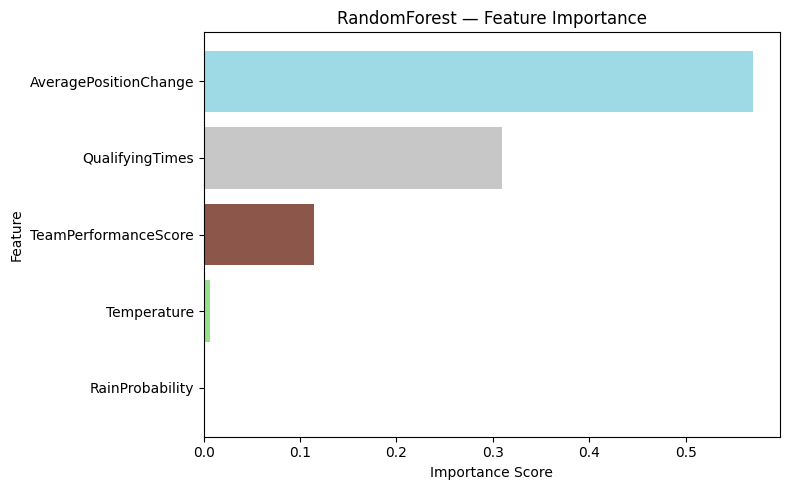

In [612]:

feature_names = list(x.columns)
feature_importance = best_model.feature_importances_  # note: spelling fixed
fi_df = (pd.DataFrame({"Feature": feature_names, "Importance": feature_importance})
           .sort_values("Importance"))

colors = plt.cm.tab20(np.linspace(0, 1, len(fi_df)))
plt.figure(figsize=(8,5))
plt.barh(fi_df["Feature"], fi_df["Importance"], color=colors)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title(f"{best_name} — Feature Importance")
plt.tight_layout()
plt.show()

In [613]:
# Retrain a simple RF with the strongest features only
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# keep only the impactful features
x_small = final_df[["QualifyingTimes","TeamPerformanceScore","AveragePositionChange"]].copy()

imp = SimpleImputer(strategy="median")
x_small_imp = imp.fit_transform(x_small)

x_tr, x_te, y_tr, y_te = train_test_split(x_small_imp, y, test_size=0.30, random_state=37)

rf = RandomForestRegressor(n_estimators=500, random_state=37, n_jobs=-1)
rf.fit(x_tr, y_tr)
pred = rf.predict(x_te)

rmse = np.sqrt(mean_squared_error(y_te, pred))
r2   = r2_score(y_te, pred)
print(f"RF (trimmed features) — RMSE: {rmse:.3f}  R²: {r2:.3f}")

# predict all drivers and compare
x_all_small_imp = SimpleImputer(strategy="median").fit_transform(x_small)
final_df["Predicted_s_trimmed"] = rf.predict(x_all_small_imp)

fi = pd.Series(rf.feature_importances_, index=["QualifyingTimes","TeamPerformanceScore","AveragePositionChange"])
display(fi.sort_values(ascending=False).round(3))

display(
    final_df[["Driver","QualifyingTimes","Predicted_s_trimmed","Target_s"]]
      .sort_values("Target_s")
      .head(12)
)


RF (trimmed features) — RMSE: 0.627  R²: -0.590


,0
AveragePositionChange,0.550
QualifyingTimes,0.301
TeamPerformanceScore,0.149


,Driver,QualifyingTimes,Predicted_s_trimmed,Target_s
3,NOR,72.021,85.118356,84.773000
2,VER,72.000,85.501514,85.230490
1,HAM,71.979,85.276738,85.407918
4,PIA,72.103,86.204022,85.494140
0,RUS,71.742,85.632935,85.497065
6,ALO,72.228,86.443262,85.637061
13,MAG,72.916,86.819389,86.192106
18,HUL,73.978,87.426112,86.352298
9,STR,72.659,86.611499,86.548061
14,GAS,72.940,86.838901,86.709820
